# Colab Base para el Trabajo Práctico (Entrega 3)



## Informe del notebook

Este notebook realiza un flujo completo de preparación de datos, detección de outliers, ingeniería de variables, selección y entrenamiento de modelo, y generación de una solución para subir a Kaggle.

### Pasos principales realizados

1. **Lectura de datos**
   - Importa datos de entrenamiento desde `data/raw/entrenamiento.csv`.
   - Carga los datos a predecir desde `data/a_predecir.csv`.

2. **Filtrado inicial**
   - Filtra el dataset de entrenamiento por país, provincia, tipo de operación, tipo de propiedad, moneda y rango de precio.
   - El objetivo es trabajar solo con casos de `venta` en `dólares` y propiedades residenciales válidas.

3. **Ingeniería de variables**
   - Crea la columna `texto` uniendo `features` y `description` en minúsculas.
   - Extrae variables numéricas desde el texto: `c_dormitorios`, `c_baños`, `c_ambientes`, `superficie`.
   - Genera indicadores binarios para amenidades como `con_pileta`, `con_garage`, `con_ascensor`, `con_parque`, `a_estrenar`, etc.
   - Estandariza `property_type` reemplazando `casas` por `casa` y `departamentos` por `departamento`.

4. **Precio por metro cuadrado**
   - Calcula `price_m2 = price / superficie`.
   - Agrupa por `property_type` y `location_2` para obtener el promedio de `price_m2` por barrio.
   - Mezcla ese promedio de vuelta al dataset.

5. **Codificación de variables categóricas**
   - Genera variables dummy para `property_type`.
   - En la parte de predicción, también codifica `property_type` con `get_dummies()`.

6. **Detección y eliminación de outliers**
   - Define función `detect_atipico_iqr()` usando el método IQR.
   - Detecta outliers por precio de `departamento` y `casa` por separado.
   - Detecta outliers por `superficie`, `cantidad de baños` y `ambientes`.
   - Alinea las máscaras booleanas con el índice original y elimina las filas outlier de `df_ent`.

7. **Imputación de valores faltantes**
   - Imputa valores nulos de `address`, `description`, `features`, `location_3`, `location_4`, `source` con valores de texto.
   - Imputa `publication_date` y `publisher_id` con la moda.
   - Imputa `c_dormitorios`, `c_baños`, `c_ambientes` con la moda.
   - Imputa `superficie` con el promedio.
   - Recalcula medias de `lon` y `lat` por `location_2`.

8. **Reducción de dimensionalidad y selección de variables**
   - Aplica `SelectKBest(chi2)`, correlación y RFE para explorar qué variables son más relevantes.
   - Utiliza `RandomForestRegressor` para seleccionar características.

9. **Entrenamiento del modelo**
   - Ajusta un `RandomForestRegressor` con `train_test_split`.
   - Calcula errores RMSE en entrenamiento y prueba.
   - Incluye una sección opcional de búsqueda de hiperparámetros con `GridSearchCV`.

10. **Generación de la solución para Kaggle**
    - Aplica la misma transformación al dataset `df_ap`.
    - Predice `price` con el modelo entrenado.
    - Guarda las predicciones en un archivo CSV de salida.

### Observaciones

- El notebook mezcla operaciones de exploración, limpieza y modelado en un solo flujo.
- La parte crítica es mantener la alineación de índices cuando se calculan outliers por subconjuntos.
- El informe resume cada bloque de trabajo y permite seguir el proceso de preparación hasta la entrega.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics

import spacy

import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Lectura de datos

In [2]:
# TODO: Cambiar para que apunte al directorio correcto
DIR_colab = "/content/drive/MyDrive" + "/UBA/Especializacion/DM/Data"
DIR_local = "../data"

In [140]:
engine = sqlite3.connect(f"{DIR_local}/entrenamiento.db")

df_ent = pd.read_sql("SELECT * FROM entrenamiento", engine, index_col="id")

## 1.Entender los datos (AID)
```python
df_ent.columns
df_ent.shape()
df_ent.describe()
df_ent.info()

print(f"Dataset a predecir - Operaciones:\n-{df_ap.operation_type.unique()}\n")
print(f"Dataset a entrenar - Operaciones:\n-{df_ent.operation_type.unique()}")
print("-"*90)

print(f"Dataset a predecir - Propiedad:\n-{df_ap.property_type.unique()}\n")
print(f"Dataset a entrenar - Propiedad:\n-{df_ent.property_type.unique()}")
print("-"*90)

print(f"Dataset a predecir - País:\n-{df_ap.location_0.unique()}\n")
print(f"Dataset a entrenar - País:\n-{df_ent.location_0.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Provincia:\n-{df_ap.location_1.unique()}\n")
print(f"Dataset a entrenar - Provincia:\n-{df_ent.location_1.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Ciudad:\n-{df_ap.location_2.unique()}\n")
print(f"Dataset a entrenar - Ciudad:\n-{df_ent.location_2.unique()}")
print("-"*90)

print(f"Dataset a predecir - Moneda:\n-{df_ap.currency_type.unique()}\n")
print(f"Dataset a entrenar - Moneda:\n-{df_ent.currency_type.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Fuente de datos:\n-{df_ap.source.unique()}\n")
print(f"Dataset a entrenar - Fuente de datos:\n-{df_ent.source.unique()}\n")
print("-"*90)
```

## 2.Limpiar y transformar los datos (DM)

## 2.1. Filtrado de datos
``` python
# Selección de datos. Solo a fines demostrativos.
# TODO: CAMBIAR!
# Entrenamiento se basa en los parámentreos lon y lat, este filtro lo haremos por geolocalización,
#  operación, tipo de propiedad, moneda, fuente de datos
filtro = ((df_ent["location_0"] == 'Argentina') &
 (df_ent["location_1"].isin(['Ciudad Autónoma de Buenos Aires','Capital Federal', 'CABA'])) &
          (df_ent["operation_type"] == "venta") &
          (df_ent["property_type"].isin(['casa','departamento', "departamentos", "casas"])) &
          (df_ent["currency_type"].isin(['dolares']))   &
          (df_ent["price" ] < 700000) &
          (~df_ent["price"].isna()) &
           (df_ent["price"]!=0))
df_ent = df_ent.loc[filtro]
df_ent.shape
```


Una vez definido el filtrado de información, se guarda el dataset en un csv. De forma tal, que en los próximos análisis, evite la conexión a la base de datos y el proceso de filtrado.
```python
# Guardo el dataframe en un csv, para luego acceder más facil.
df_ent.to_csv("/content/drive/MyDrive/UBA/Especializacion/DM/Data/raw/entrenamiento.csv")
```

In [19]:
df_ent.shape

(0, 50)

In [141]:
filtro = ((df_ent["location_0"] == 'Argentina') &
 (df_ent["location_1"].isin(['Ciudad Autónoma de Buenos Aires','Capital Federal', 'CABA'])) &
          (df_ent["operation_type"] == "venta") &
          (df_ent["property_type"].isin(['casa','departamento', "departamentos", "casas"])) &
          (df_ent["currency_type"].isin(['dolares']))   &
        #   (df_ent["price" ] < 700000) &
          (~df_ent["price"].isna()) &
           (df_ent["price"]!=0))
df_ent = df_ent.loc[filtro]
df_ent.shape

(110812, 17)

## 2.2 Creación de nuevos atributos

In [432]:
# Lectura del archivo filtrado.
# df_ent = pd.read_csv("/content/drive/MyDrive/UBA/Especializacion/DM/Data/raw/entrenamiento.csv", index_col="id")
df_ent = pd.read_csv(f"{DIR_local}/raw/entrenamiento.csv", index_col="id")
df_ent.shape

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_23740\4019824099.py:3: DtypeWarning: Columns (0: publisher_id, 1: operation_type) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ent = pd.read_csv(f"{DIR_local}/raw/entrenamiento.csv", index_col="id")


(106186, 17)

Para poder ver la tablas en un ancho definido y no  acotada. Esto mejora la visualización

In [55]:
# Muestra sin restricción
pd.set_option('display.max_colwidth', None)
# retoran a la configuración de fábrica
# pd.reset_option('display.max_colwidth')

**Anáisis del atributo features**

con el comando extract utilizando expresiones regulares.\
Atributos posibles:


*   baños
*   dormitorios
*   superficie
*   superficie cubierta




In [142]:
# creamos otras variables
texto = (
    df_ent["features"].fillna("").astype(str) + " " +
    df_ent["description"].fillna("").astype(str)
)
# pasamos a minúscula para evitar problemas de mayúsculas/minúsculas
texto = texto.str.lower()
df_ent["texto"] = texto
# df_ent["texto"].head() 



In [143]:
# creamos otras variables
texto = (
    # df_ent["features"].fillna("").astype(str) + " " +
    df_ent["description"].fillna("").astype(str)
)
# pasamos a minúscula para evitar problemas de mayúsculas/minúsculas
texto = texto.str.lower()
df_ent["text_mining"] = texto
# df_ent["texto"].head() 

In [144]:

# dormitorios
patron = r"(\d+) dormitorios;|dormitorio: (\d+);|dormitorios:(\d+);|(\d+)\s*habitaciones"
dormitorios = texto.str.extract(patron, expand=False)
df_ent["c_dormitorios"] = pd.to_numeric(dormitorios[0].fillna(dormitorios[1]).fillna(dormitorios[2]).fillna(dormitorios[3]))

#
# baños
patron = r"(\d+) baños;|bano: (\d+);|baños:(\d+);|(\d+)\s*banos"
banios = texto.str.extract(patron, expand=False)
df_ent["c_baños"] = pd.to_numeric(banios[0].fillna(banios[1]).fillna(banios[2]).fillna(banios[3]))

# ambientes
patron = r"(\d+)\s*(?:ambientes?|rooms?)"
ambientes = texto.str.extract(patron, expand=False)
df_ent["c_ambientes"] = pd.to_numeric(ambientes)


# # el garage solo anotaremos tiene SI(1) o NO(0)
# garage = texto.str.extract(r'(garage);|(cochera):|(cocheras):\d+')
# df_ent["garage"]  = garage[0].fillna(garage[1]).fillna(garage[2])
# df_ent["con_garage"] = int(0)
# df_ent.loc[~df_ent["garage"].isna(), "con_garage"] = int(1)

# Superficie
patron = r";(\d+)\s*m²|scubierta: (\d+);| superficie total:(\d+)m.{1};|sup.\scubierta:(\d+)\s*m²| tcubierta:\s(\d*,\d*)\sm²| superficie\stotal:\s(\d+)"
superficie = texto.str.extract(patron, expand=False)
df_ent["superficie"] = pd.to_numeric(superficie[0].fillna(superficie[1]).fillna(superficie[2]).fillna(superficie[3]).fillna(superficie[4]).fillna(superficie[5]))   


df_ent["con_pileta"] = 0
df_ent.loc[df_ent["texto"].str.contains("pileta"), "con_pileta"] = 1
df_ent["con_jardin"] = 0
df_ent.loc[df_ent["texto"].str.contains("jardin"), "con_jardin"] = 1
df_ent["con_seguridad"] = 0
df_ent.loc[df_ent["texto"].str.contains("seguridad"), "con_seguridad"] = 1
df_ent["con_gas"] = 0
df_ent.loc[df_ent["texto"].str.contains("gas"), "con_gas"] = 1
df_ent["con_ascensor"] = 0
df_ent.loc[df_ent["texto"].str.contains("ascensor"), "con_ascensor"] = 1
df_ent["con_lavadero"] = 0
df_ent.loc[df_ent["texto"].str.contains("lavadero"), "con_lavadero"] = 1
df_ent["con_aire_acondicionado"] = 0
df_ent.loc[df_ent["texto"].str.contains("aire acondicionado"), "con_aire_acondicionado"] = 1
df_ent["con_calefaccion"] = 0
df_ent.loc[df_ent["texto"].str.contains("calefaccion"), "con_calefaccion"] = 1
df_ent["con_terraza"] = 0
df_ent.loc[df_ent["texto"].str.contains("terraza"), "con_terraza"] = 1
df_ent["con_balcon"] = 0
df_ent.loc[df_ent["texto"].str.contains("balcon"), "con_balcon"] = 1
df_ent["con_amoblado"] = 0
df_ent.loc[df_ent["texto"].str.contains("amoblado"), "con_amoblado"] = 1
df_ent["con_vigilancia"] = 0
df_ent.loc[df_ent["texto"].str.contains("vigilancia"), "con_vigilancia"] = 1
df_ent["con_electricidad"] = 0
df_ent.loc[df_ent["texto"].str.contains("electricidad"), "con_electricidad"] = 1
df_ent["con_ventilacion"] = 0
df_ent.loc[df_ent["texto"].str.contains("ventilacion"), "con_ventilacion"] = 1
df_ent["con_escuela_cercana"] = 0
df_ent.loc[df_ent["texto"].str.contains("escuela cercana"), "con_escuela_cercana"] = 1
df_ent["con_transporte_cercano"] = 0
df_ent.loc[df_ent["texto"].str.contains("transporte cercano"), "con_transporte_cercano"] = 1
df_ent["con_comercio_cercano"] = 0
df_ent.loc[df_ent["texto"].str.contains("comercio cercano"), "con_comercio_cercano"] = 1
df_ent["con_parque"] = 0
df_ent.loc[df_ent["texto"].str.contains("parque"), "con_parque"] = 1
df_ent["con_gimnasio"] = 0
df_ent.loc[df_ent["texto"].str.contains("gimnasio"), "con_gimnasio"] = 1
df_ent["con_sauna"] = 0
df_ent.loc[df_ent["texto"].str.contains("sauna"), "con_sauna"] = 1
df_ent["a_estrenar"] = 0
df_ent.loc[df_ent["texto"].str.contains("a estrenar"), "a_estrenar"] = 1
df_ent["con_quincho"] = 0
df_ent.loc[df_ent["texto"].str.contains("quincho"), "con_quincho"] = 1
df_ent["cerca_subte"] = 0
df_ent.loc[df_ent["texto"].str.contains("subte"), "cerca_subte"] = 1
df_ent["cocheara"] = 0
df_ent.loc[df_ent["texto"].str.contains("cochera|cocheras|coch|garage",
                                         regex=True), "cocheara"] = 1
df_ent["luminoso"] = 0
df_ent.loc[df_ent["texto"].str.contains("luminoso"), "luminoso"] = 1

# estandarizo el tipo de propiedad para quedarnos con solo "casa" y "departamento"
casa_departamento = {
    "casas" : "casa",
    "departamentos" : "departamento"
}
df_ent["property_type"] = df_ent["property_type"].replace(casa_departamento)


# creo la variable precio por metro cuadrado
df_ent["price_m2"] = df_ent["price"] / (df_ent["superficie"])
gb = df_ent.groupby(by=["property_type", "location_2"])["price_m2"].mean().reset_index()

# # me quedo con el promedio por tipo de propiedad y barrio.
# df_ent = df_ent[df_ent.columns.drop("price_m2")].merge(gb, on=["property_type", "location_2"], how="left")

# # filtro lo que tiene un precio por metro cuadrado sin sentido para calular la estadistica
# # df_ent = df_ent[(df_ent["price_m2"] >= 300) & (df_ent["price_m2"] <= 9000)]
# df_ent = df_ent[(df_ent["price_m2"] >= 300) ]



# Código para label encoding acá
colnames = ['property_type']
# df_ent = pd.get_dummies(df_ent, columns=colnames, dummy_na=True, dtype=int)
dummies = pd.get_dummies(df_ent[colnames], dtype=int)
df_ent = pd.concat([df_ent, dummies], axis=1)

df_ent.shape

(110812, 51)

In [66]:
df_ent.isna().sum()

description                        2
address                          483
lat                            63906
lon                            63905
publication_date               63905
publisher_id                   31730
features                         102
location_0                         0
location_1                         0
location_2                         4
location_3                     17532
location_4                    103329
operation_type                     0
property_type                      0
source                          1398
price                              0
currency_type                      0
texto                              0
c_dormitorios                 107141
c_baños                       110747
c_ambientes                    41029
superficie                    107844
con_pileta                         0
con_jardin                         0
con_seguridad                      0
con_gas                            0
con_ascensor                       0
c

## 2.3. Tratamiento de valores atípicos

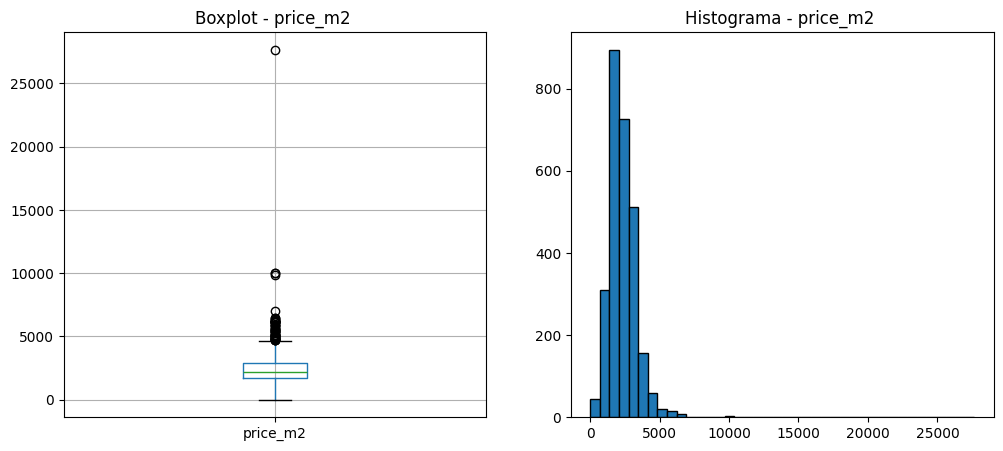

In [172]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(column="price_m2", ax=ax1)
ax1.set_title("Boxplot - price_m2 ")

ax2.hist(df_ent["price_m2"], bins=40, edgecolor='black')
ax2.set_title("Histograma - price_m2 ")

plt.show()

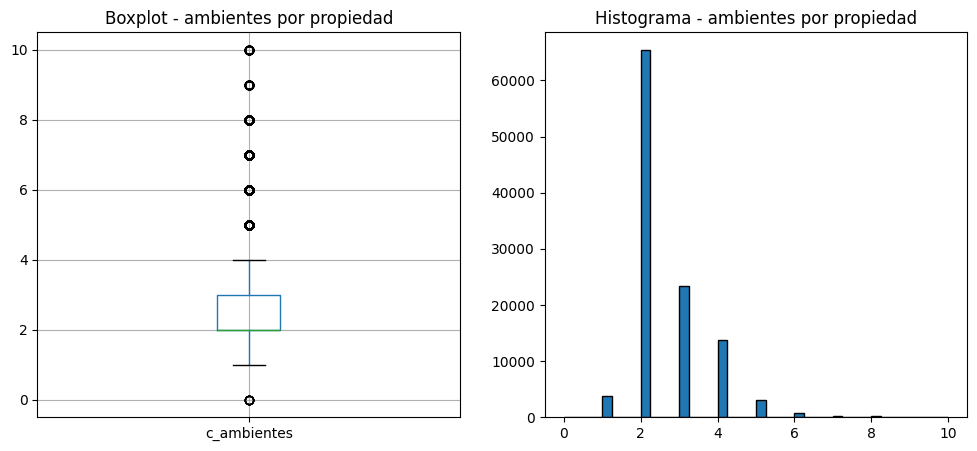

In [171]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(column="c_ambientes", ax=ax1)
ax1.set_title("Boxplot - ambientes por propiedad")

ax2.hist(df_ent["c_ambientes"], bins=40, edgecolor='black')
ax2.set_title("Histograma - ambientes por propiedad")

plt.show()

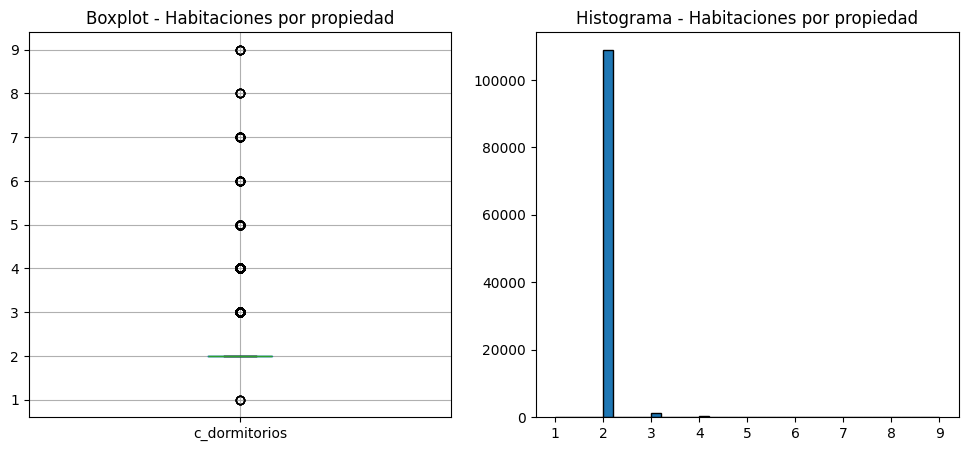

In [170]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(column="c_dormitorios", ax=ax1)
ax1.set_title("Boxplot - Habitaciones por propiedad")

ax2.hist(df_ent["c_dormitorios"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Habitaciones por propiedad")

plt.show()

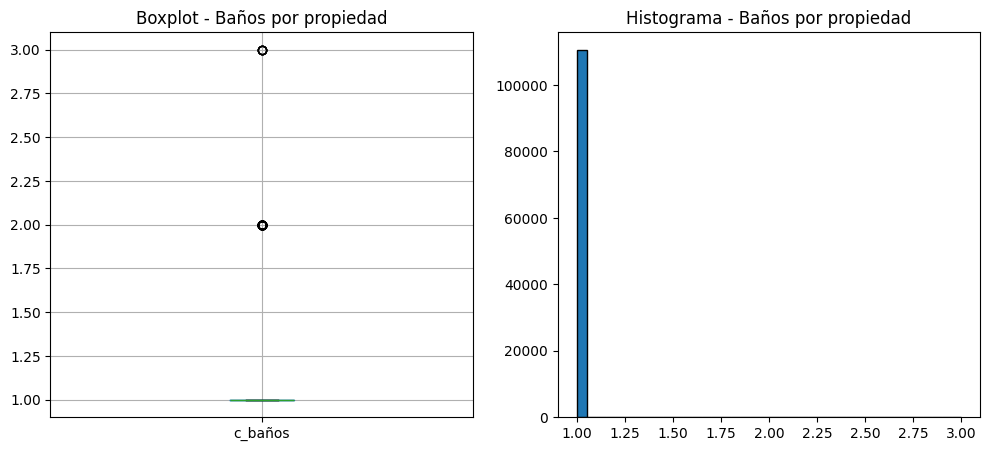

In [169]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(column="c_baños", ax=ax1)
ax1.set_title("Boxplot - Baños por propiedad")

ax2.hist(df_ent["c_baños"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Baños por propiedad")

plt.show()

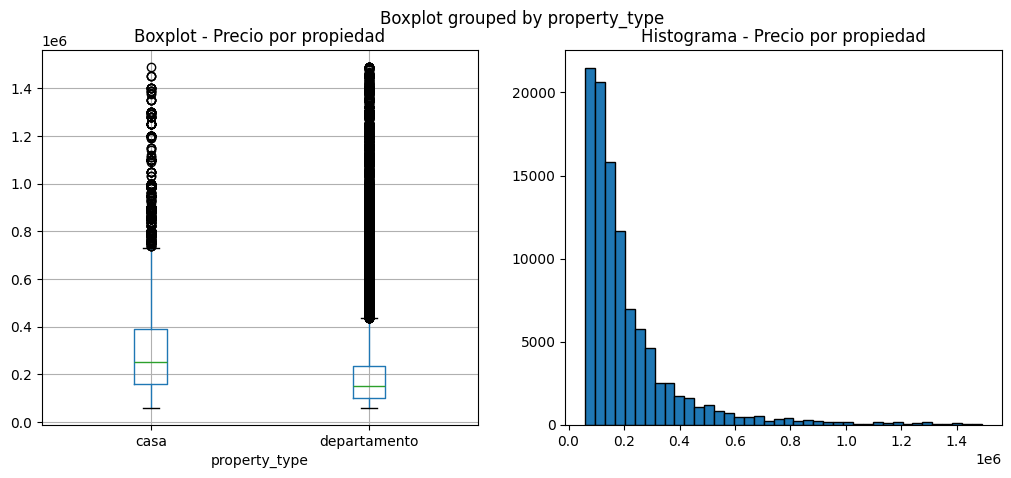

In [174]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por propiedad")

ax2.hist(df_ent["price"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Precio por propiedad")

plt.show()

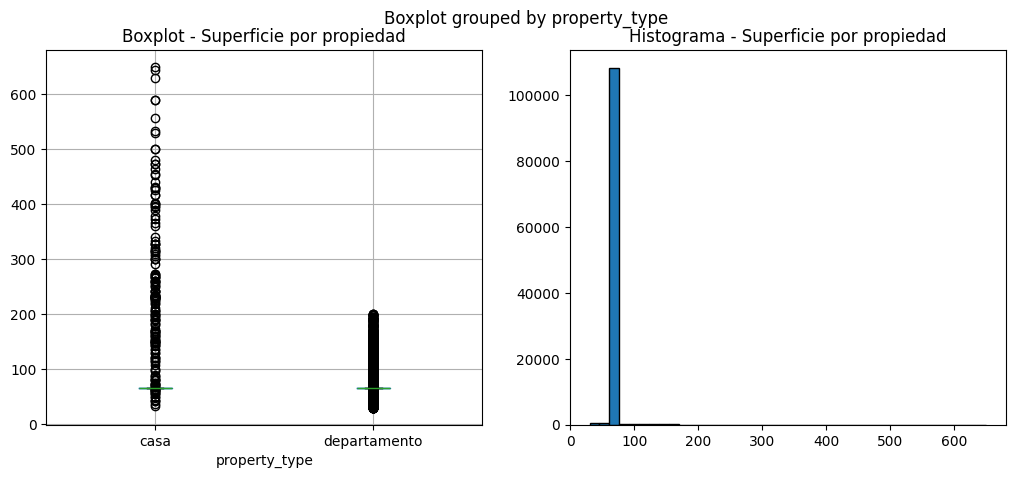

In [166]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="superficie", ax=ax1)
ax1.set_title("Boxplot - Superficie por propiedad")

ax2.hist(df_ent["superficie"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Superficie por propiedad")

plt.show()

**Detección por rango intercuartil**\
Muestra una mayor cantidad de valores atípicos en el precio de los departamientos.

In [43]:
def detect_atipico_iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - (iqr * 1.5)
    lim_sup = q3 + (iqr * 1.5)
    return (x < lim_inf) | (x > lim_sup)
    
def detect_atipico_iqr_2(x):
    lim_inf, lim_sup = np.percentile(x, [5, 99])
    # iqr = q3 - q1
    # lim_inf = q1
    # lim_sup = q3
    return (x < lim_inf) | (x > lim_sup)

In [161]:
# df_ent["superficie"] = df_ent.loc[(df_ent["superficie"] < 1500) & (df_ent["superficie"] > 4), "superficie"]
outlier_casa_sup =((df_ent["property_type"] == "casa") & 
                             ((df_ent["superficie"] > 800) | (df_ent["superficie"] < 30)))
outlier_departamento_sup = ((df_ent["property_type"] == "departamento") & 
                                      ((df_ent["superficie"] > 200) | (df_ent["superficie"] < 30)))

In [164]:
# me quedo con percentil 5 y 99 de superficie, porque más de 400 m2 no tiene sentido.
df_ent = df_ent[~outlier_casa_sup]
df_ent = df_ent[~outlier_departamento_sup]

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_9004\2564995720.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ent = df_ent[~outlier_departamento_sup]


In [173]:
# me quedo con los que tienen menos de 10 dormitorios, porque más de 10 no tiene sentido.
df_ent = df_ent[df_ent["c_dormitorios"] < 10]

# me quedo con los que tienen menos de 11 ambientes, porque más de 11 no tiene sentido.
df_ent = df_ent[df_ent["c_ambientes"] < 11]

# me quedo con los que tienen menos de 5 baños, porque más de 5 no tiene sentido.
df_ent = df_ent[df_ent["c_baños"] < 5]

# # me quedo con percentil 5 y 99 de superficie, porque más de 400 m2 no tiene sentido.
# outliers_iqr_superficie = detect_atipico_iqr_2(df_ent["superficie"])
# df_ent = df_ent[~outliers_iqr_superficie]

# me quedo con percentil 5 y 99 de precio, porque más de 2000000 no tiene sentido.
outliers_iqr_precio = detect_atipico_iqr_2(df_ent["price"])
df_ent = df_ent[~outliers_iqr_precio]

df_ent.shape

(103986, 51)

In [82]:
df_ent.shape

(101818, 50)

Analizo precio de la propiedad por Barrio

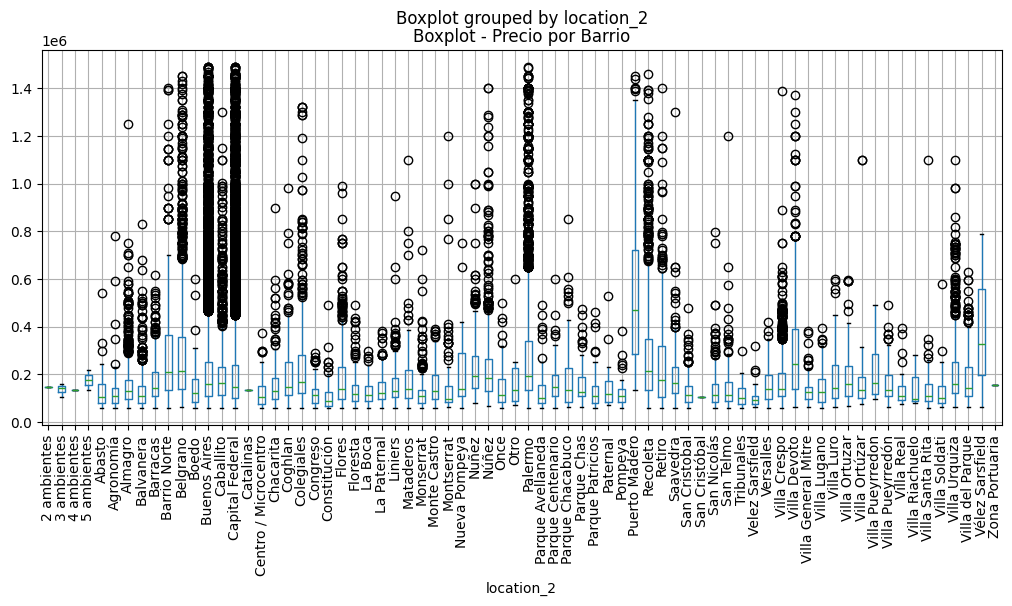

In [175]:
fig, ax1 = plt.subplots(figsize=(12, 5))

df_ent.boxplot(by="location_2", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por Barrio")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


plt.show()

Se observa en el campo barrio (location_2): 2 ambientes, 3 ambientes, 4 ambientes, 5 ambientes
Se observa outliers en location_2: Palermo, Capital Federal, Buenos Aires, Villa Crespo y Villa Urquiza principalmente.


## 2.4. Imputación de valores perdidos

Me voy a enfocar en las siguientes variables:
1. description       106184 non-null  object
2.   address           105719 non-null  object
3.   lat               44691 non-null   float64
4.   lon               44692 non-null   float64
5.   publication_date  44692 non-null   object
6.   publisher_id      75848 non-null   float64
7.   features
8. source            104804 non-null  object  

In [133]:
df_ent["c_baños"].value_counts()

c_baños
1.0    110756
2.0        50
3.0         5
4.0         1
Name: count, dtype: int64

In [145]:
# Address NA se imputa con "sin info"
df_ent["address"].fillna("sin info", inplace=True)

# Description NA se imputa con "sin info"
df_ent["description"].fillna("sin info", inplace=True)

# La moda de primera mano no sirve, porque el dato es basura (photo)
# Me quedo con el segundo valor de la moda "23 nov 2022"
df_ent.loc[df_ent['publication_date'] == "photo", "publication_date"] = "23 nov 2022"
# Ahora reemplazo los NA con la moda
public_dat_moda = df_ent['publication_date'].mode()[0]
df_ent['publication_date'].fillna(public_dat_moda, inplace=True)


# Imputo PUBLISHER por la moda
publi_id_moda = df_ent["publisher_id"].mode()[0]
df_ent["publisher_id"] = df_ent["publisher_id"].fillna(publi_id_moda)
# casteo a entero
df_ent["publisher_id"] = df_ent["publisher_id"].astype(int)


# Imputo FEATURES con "sin info"
df_ent["features"].fillna("sin info", inplace=True)


# imputo LOCATION 3 y 4 con "sin info"
df_ent["location_3"].fillna("sin info", inplace=True)
df_ent["location_4"].fillna("sin info", inplace=True)


# imputo SOURCE con "sin info"
df_ent["source"].fillna("sin info", inplace=True)

# imputo cantidad de DORMITORIOS con la moda
# df_ent["c_dormitorios"] = df_ent["c_dormitorios"].astype(int, errors="ignore") # convierto a numerico
cant_dormitorio_moda = int(df_ent["c_dormitorios"].mode()[0]) # calculo la moda
df_ent["c_dormitorios"] = df_ent["c_dormitorios"].fillna(cant_dormitorio_moda)


# Imputo cantidad BAÑOS con la moda
# df_ent["c_baños"] =  df_ent["c_baños"].astype(int, errors="ignore")  # convierto a numerico
# banio_moda = int(df_ent["c_baños"].mode()[0])       # calculo la moda
banio_moda = 1
df_ent["c_baños"] = df_ent["c_baños"].fillna(banio_moda)

# # imputo SUPERFICIE con mediana
# df_ent['superficie'] = df_ent['superficie'].astype(float)                 # convierto a numerico
superficie_promedio = df_ent['superficie'].median().round(2)  # mediana
df_ent['superficie'] = df_ent['superficie'].fillna(superficie_promedio)

# imputo cantidad de AMBIENTES con la moda
hambientes_moda = int(df_ent["c_ambientes"].mode()[0])       # calculo la moda
df_ent["c_ambientes"] = df_ent["c_ambientes"].fillna(hambientes_moda)

# dataframe location_2 con lon y lat
geo = df_ent.groupby(by=["location_2"])[["lon", "lat"]].median().reset_index()
# me quedo con el promedio por tipo de propiedad y barrio.
df_ent = df_ent[df_ent.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left")

print(df_ent.isna().sum())

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_9004\1238961652.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ent["address"].fillna("sin info", inplace=True)
C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_9004\1238961652.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

description                        2
address                          483
publication_date               63905
publisher_id                       0
features                         102
location_0                         0
location_1                         0
location_2                         4
location_3                     17532
location_4                    103329
operation_type                     0
property_type                      0
source                          1398
price                              0
currency_type                      0
texto                              0
text_mining                        0
c_dormitorios                      0
c_baños                            0
c_ambientes                        0
superficie                         0
con_pileta                         0
con_jardin                         0
con_seguridad                      0
con_gas                            0
con_ascensor                       0
con_lavadero                       0
c

Estandarizamos la manera en que nombramos a las casas y a los departamentos

### Nuevos atributos
* precio m2 por barrio
* cerca de transporte publico
* seguridad - vigilancia - amenitis
* A estrenar - A refaccionar
* Pileta
* Iluminación
* Antiguedad
* Balcon 

## 2.5. Campos calculados

In [176]:
# creo la variable precio por metro cuadrado
df_ent["price_m2"] = df_ent["price"] / (df_ent["superficie"])
gb = df_ent.groupby(by=["property_type", "location_2"])["price_m2"].mean().reset_index()

# me quedo con el promedio por tipo de propiedad y barrio.
df_ent = df_ent[df_ent.columns.drop("price_m2")].merge(gb, on=["property_type", "location_2"], how="left")

# filtro lo que tiene un precio por metro cuadrado sin sentido para calular la estadistica
# df_ent = df_ent[(df_ent["price_m2"] >= 300) & (df_ent["price_m2"] <= 9000)]
df_ent = df_ent[(df_ent["price_m2"] >= 300) ]


df_ent["price_total"] = df_ent["price_m2"] * (df_ent["superficie"])

In [208]:
# creo la variable con_suite que indica si el texto tiene la palabra suite o no,
#  porque es un dato que puede ser relevante para el precio.
df_ent["con_suite"] = 0
df_ent.loc[df_ent["texto"].str.contains("suite"), "con_suite"] = 1



Backup

In [181]:
df_ent.to_csv(f"{DIR_local}/processed/entrenamiento_procesado.csv", index=True)

## 2.6 Text mining

In [193]:
# Cargo el modelo de spacy para español
nlp = spacy.load("es_core_news_sm")

df = df_ent.sample(frac=0.1, random_state=42)
df.shape


(10398, 52)

In [194]:
# tokenizo el texto con spacy
df['texto_tok'] = df['text_mining'].apply(lambda texto: [token.text for token in nlp(texto)])
df['texto_tok']


24606                                                                        [monoambiente, muy, luminoso, en, el, corazón, de, palermo, !, ideal, para, inversión, y, apto, profesional, !, superficie, total, 38m2, descripción, :, -, amplio, y, luminoso, monoambiente, divisible, (, hoy, dividido, por, mueble, móvil, al, ingresar, ), ., -, cocina, con, espacio, de, guardado, y, ventana, a, exterior, ., -, amplio, baño, completo, con, bañadera, ., -, ventana, con, persianas, nuevas, .,   , detalles, :, -, aire, acondicionado, frio, calor, ., -, pisos, de, parquet, sano, y, original, ,, están, lijados, pero, no, plastificados, .,   , -, agua, caliente, calefón, a, gas, .,   , -, conexión, para, estufa, tiro, balanceado, ., ...]
58711                   [increible, 2, ambientes, a, estrenar, en, venta, -, chacarita,                                       , distrito, maure, -, excelente, 2, ambientes, al, frente, en, venta, .,  , amplio, living, comedor, con, salida, a, balcón, con, vista, al,

In [195]:

# elimino stopwords
stopwords = nlp.Defaults.stop_words
df['texto_tok'] = df['texto_tok'].apply(lambda texto: [token for token in texto if token not in stopwords])
df['texto_tok']


24606                                                                                                                        [monoambiente, luminoso, corazón, palermo, !, ideal, inversión, apto, profesional, !, superficie, 38m2, descripción, :, -, amplio, luminoso, monoambiente, divisible, (, dividido, mueble, móvil, ingresar, ), ., -, cocina, espacio, guardado, ventana, exterior, ., -, amplio, baño, completo, bañadera, ., -, ventana, persianas, .,   , detalles, :, -, aire, acondicionado, frio, calor, ., -, pisos, parquet, sano, original, ,, lijados, plastificados, .,   , -, agua, caliente, calefón, gas, .,   , -, conexión, estufa, tiro, balanceado, ., -, cocina, horno, gas, ,, mesada, granito, espacio, guardado, ., -, sol, directo, mediodía, .,   , -, ascensor, automático, ., -, edifico, encargado, ., ubicación, ...]
58711                                              [increible, 2, ambientes, estrenar, venta, -, chacarita,                                       , distrito, maure, -, ex

In [196]:
# vuelvo a unir los tokens para tener el texto limpio sin stopwords
df['texto'] = df['texto_tok'].str.join(' ')
df['texto']



24606                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [197]:

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 3), min_df=0.005, max_df=0.7, strip_accents='ascii', max_features=2000)
vectorized_data = vectorizer.fit_transform(df['texto'])
vectorized_data.toarray()
len(vectorizer.get_feature_names_out().tolist())


2000

In [198]:


count_df = pd.DataFrame(vectorized_data.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)
count_df


,00,000,028,028 ley,028 ley 22,028 ley nacional,10,10 973,10 973 provincia,100,...,vivir,vivir invertir,web,web plataforma,web plataforma oficina,whatsapp,yeso,zona,zona residencial,zonas
24606,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
58711,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
24016,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
76905,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38778,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72147,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
36925,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
31778,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60223,2,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [199]:

df_ent2 = count_df.merge(df_ent[["price"]], left_index=True, right_index=True)

## Reducción de dimensionalidad

### Eliminación recursiva de atributos

In [150]:
df2 = df_ent.select_dtypes('number')
X = df2[df2.columns.drop('price')]
y = df2['price']

reg = sk.ensemble.RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1)

# n_features_to_select --> nro atributos a seleccionar
# step --> cuantos atributos a eliminar en cada paso
selector = sk.feature_selection.RFE(reg, n_features_to_select=25, step=1)
selector = selector.fit(X, y)

print(selector.support_)
print(selector.ranking_)
print(selector.get_feature_names_out())

[ True  True  True  True  True  True  True  True  True False  True False
 False  True False False  True False False False False False  True  True
  True  True False  True  True  True  True  True  True  True  True  True]
[ 1  1  1  1  1  1  1  1  1  4  1  2  7  1  3  8  1  6  9 11 10 12  1  1
  1  1  5  1  1  1  1  1  1  1  1  1]
['publisher_id' 'c_dormitorios' 'c_baños' 'c_ambientes' 'superficie'
 'con_pileta' 'con_jardin' 'con_seguridad' 'con_gas' 'con_lavadero'
 'con_terraza' 'con_vigilancia' 'con_parque' 'con_gimnasio' 'con_sauna'
 'a_estrenar' 'cerca_subte' 'cocheara' 'luminoso' 'property_type_casa'
 'property_type_departamento' 'lon' 'lat' 'price_m2' 'price_total']


### Duplicados

In [159]:
df_ent = df_ent.drop_duplicates()

## Antes de entrenar, hacer backup

In [151]:
# Ante de entrenar, hacer backup
df_ent_bkp = df_ent.copy()
# df_ent = df_ent_bkp.copy()

## 3. Entrenamiento del modelos (AA)- ⛔⛔⛔ NO TOCAR NADA DE ESTA SECCIÓN ⛔⛔⛔

In [200]:
# La creación de modelos requiere que todo el dataframe sea numérico
# Me quedo con las columnas numéricas solamente
# df_ent = df_ent.select_dtypes('number')

X = df_ent2[df_ent2.columns.drop('price')]
# X = df_ent[selector.get_feature_names_out()]
# X = X.drop(columns=["c_baños"])
# X = df_ent[columnas]
y = df_ent2['price']

In [201]:
X.columns

Index(['00', '000', '028', '028 ley', '028 ley 22', '028 ley nacional', '10',
       '10 973', '10 973 provincia', '100',
       ...
       'vivir', 'vivir invertir', 'web', 'web plataforma',
       'web plataforma oficina', 'whatsapp', 'yeso', 'zona',
       'zona residencial', 'zonas'],
      dtype='str', length=2000)

In [202]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos el valor de los hiperparámetros a usar por el modelo
n_estimators = 300
max_depth = 30

# Creamos el modelo a entrenar
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

# Entrenamos el modelo
_ = reg.fit(X_train, y_train)

# Cálculo del error en entrenamiento (train)
y_pred = reg.predict(X_train)
score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

# Cálculo del error en prueba (test)
y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=300 -- max_depth=30 --> score_train=48542.33 - score_test=127691.32


In [90]:
# Cálculo del error en prueba (test)
# y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred))

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=300 -- max_depth=30 --> score_train=0.14 - score_test=62586.42


## 3.1. (Opcional) Optimización de hiperparámetros

In [ ]:
### Versión con train/test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

best_score_test = 10**6

### Pueden cambiar los hiperparámetros, pero no el modelo
for n_estimators in [10, 50, 100, 300]:
    for max_depth in [5, 10, 20, 30 , None]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

        # Entrenamos el modelo
        _ = reg.fit(X_train, y_train)

        # Cálculo del error en entrenamiento (train)
        y_pred = reg.predict(X_train)
        score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

        # Cálculo del error en prueba (test)
        y_pred = reg.predict(X_test)
        score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

        best_score_test = min(best_score_test, score_test)

        print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")

In [ ]:
# Versión con GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

reg = sk.ensemble.RandomForestRegressor(random_state=42)

grid_search = sk.model_selection.GridSearchCV(reg, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

## 3.2. Análisis de la importancia de variables en el modelo (opcional)

Una manera visual de entender a que variable el modelo le está prestando mayor atención.

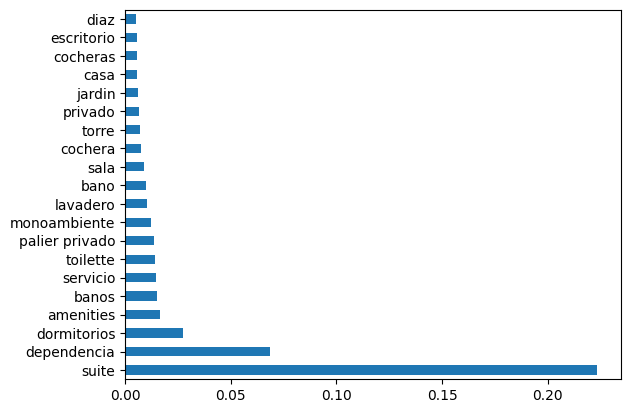

In [204]:
feat_importances = pd.Series(reg.feature_importances_, index=X.columns)

# gráfico de barras horizontales
feat_importances.nlargest(20).plot(kind='barh');

In [207]:
df_ent.columns

Index(['description', 'address', 'publication_date', 'publisher_id',
       'features', 'location_0', 'location_1', 'location_2', 'location_3',
       'location_4', 'operation_type', 'property_type', 'source', 'price',
       'currency_type', 'texto', 'text_mining', 'c_dormitorios', 'c_baños',
       'c_ambientes', 'superficie', 'con_pileta', 'con_jardin',
       'con_seguridad', 'con_gas', 'con_ascensor', 'con_lavadero',
       'con_aire_acondicionado', 'con_calefaccion', 'con_terraza',
       'con_balcon', 'con_amoblado', 'con_vigilancia', 'con_electricidad',
       'con_ventilacion', 'con_escuela_cercana', 'con_transporte_cercano',
       'con_comercio_cercano', 'con_parque', 'con_gimnasio', 'con_sauna',
       'a_estrenar', 'con_quincho', 'cerca_subte', 'cocheara', 'luminoso',
       'property_type_casa', 'property_type_departamento', 'lon', 'lat',
       'price_m2', 'price_total'],
      dtype='str')

## 4. Solución para subir Kaggle

In [156]:
df_ap = pd.read_csv(f"{DIR_local}/a_predecir.csv", index_col="id")
# df_ap.head(2)

In [118]:
df_ap.property_type.value_counts()

property_type
departamento    10817
casa             2633
cochera            21
Name: count, dtype: int64

## 4.2. Generación del archivo para Kaggle

Hacer en df_ap el mismo proceso que se realizó para los datos de entrenamiento

### **Creación de nuevos atributos**

In [ ]:
# creamos otras variables
texto = (
    df_ap["features"].fillna("").astype(str) + " " +
    df_ap["description"].fillna("").astype(str)
)
# pasamos a minúscula para evitar problemas de mayúsculas/minúsculas
texto = texto.str.lower()
df_ap["texto"] = texto



# dormitorios
patron = r"(\d+) dormitorios;|dormitorio: (\d+);|dormitorios:(\d+);|(\d+)\s*habitaciones"
dormitorios = texto.str.extract(patron, expand=False)
df_ap["c_dormitorios"] = pd.to_numeric(dormitorios[0].fillna(dormitorios[1]).fillna(dormitorios[2]).fillna(dormitorios[3]))

#
# baños
patron = r"(\d+) baños;|bano: (\d+);|baños:(\d+);|(\d+)\s*banos"
banios = texto.str.extract(patron, expand=False)
df_ap["c_baños"] = pd.to_numeric(banios[0].fillna(banios[1]).fillna(banios[2]).fillna(banios[3]))

# ambientes
patron = r"(\d+)\s*(?:ambientes?|rooms?)"
ambientes = texto.str.extract(patron, expand=False)
df_ap["c_ambientes"] = pd.to_numeric(ambientes)


# # el garage solo anotaremos tiene SI(1) o NO(0)
# garage = texto.str.extract(r'(garage);|(cochera):|(cocheras):\d+')
# df_ap["garage"]  = garage[0].fillna(garage[1]).fillna(garage[2])
# df_ap["con_garage"] = int(0)
# df_ap.loc[~df_ap["garage"].isna(), "con_garage"] = int(1)

# Superficie
patron = r";(\d+)\s*m²|scubierta: (\d+);| superficie total:(\d+)m.{1};|sup.\scubierta:(\d+)\s*m²| tcubierta:\s(\d*,\d*)\sm²| superficie\stotal:\s(\d+)"
superficie = texto.str.extract(patron, expand=False)
df_ap["superficie"] = pd.to_numeric(superficie[0].fillna(superficie[1]).fillna(superficie[2]).fillna(superficie[3]).fillna(superficie[4]).fillna(superficie[5]))   

# atributos binarios
df_ap["con_pileta"] = 0
df_ap.loc[df_ap["texto"].str.contains("pileta"), "con_pileta"] = 1
df_ap["con_jardin"] = 0
df_ap.loc[df_ap["texto"].str.contains("jardin"), "con_jardin"] = 1
df_ap["con_seguridad"] = 0
df_ap.loc[df_ap["texto"].str.contains("seguridad"), "con_seguridad"] = 1
df_ap["con_gas"] = 0
df_ap.loc[df_ap["texto"].str.contains("gas"), "con_gas"] = 1
df_ap["con_ascensor"] = 0
df_ap.loc[df_ap["texto"].str.contains("ascensor"), "con_ascensor"] = 1
df_ap["con_lavadero"] = 0
df_ap.loc[df_ap["texto"].str.contains("lavadero"), "con_lavadero"] = 1
df_ap["con_aire_acondicionado"] = 0
df_ap.loc[df_ap["texto"].str.contains("aire acondicionado"), "con_aire_acondicionado"] = 1
df_ap["con_calefaccion"] = 0
df_ap.loc[df_ap["texto"].str.contains("calefaccion"), "con_calefaccion"] = 1
df_ap["con_terraza"] = 0
df_ap.loc[df_ap["texto"].str.contains("terraza"), "con_terraza"] = 1
df_ap["con_balcon"] = 0
df_ap.loc[df_ap["texto"].str.contains("balcon"), "con_balcon"] = 1
df_ap["con_amoblado"] = 0
df_ap.loc[df_ap["texto"].str.contains("amoblado"), "con_amoblado"] = 1
df_ap["con_vigilancia"] = 0
df_ap.loc[df_ap["texto"].str.contains("vigilancia"), "con_vigilancia"] = 1
df_ap["con_electricidad"] = 0
df_ap.loc[df_ap["texto"].str.contains("electricidad"), "con_electricidad"] = 1
df_ap["con_ventilacion"] = 0
df_ap.loc[df_ap["texto"].str.contains("ventilacion"), "con_ventilacion"] = 1
df_ap["con_escuela_cercana"] = 0
df_ap.loc[df_ap["texto"].str.contains("escuela cercana"), "con_escuela_cercana"] = 1
df_ap["con_transporte_cercano"] = 0
df_ap.loc[df_ap["texto"].str.contains("transporte cercano"), "con_transporte_cercano"] = 1
df_ap["con_comercio_cercano"] = 0
df_ap.loc[df_ap["texto"].str.contains("comercio cercano"), "con_comercio_cercano"] = 1
df_ap["con_parque"] = 0
df_ap.loc[df_ap["texto"].str.contains("parque"), "con_parque"] = 1
df_ap["con_gimnasio"] = 0
df_ap.loc[df_ap["texto"].str.contains("gimnasio"), "con_gimnasio"] = 1
df_ap["con_sauna"] = 0
df_ap.loc[df_ap["texto"].str.contains("sauna"), "con_sauna"] = 1
df_ap["a_estrenar"] = 0
df_ap.loc[df_ap["texto"].str.contains("a estrenar"), "a_estrenar"] = 1
df_ap["con_quincho"] = 0
df_ap.loc[df_ap["texto"].str.contains("quincho"), "con_quincho"] = 1
df_ap["cerca_subte"] = 0
df_ap.loc[df_ap["texto"].str.contains("subte"), "cerca_subte"] = 1
df_ap.loc[df_ap["texto"].str.contains("cochera|cocheras|coch|garage",
                                         regex=True), "cocheara"] = 1
df_ap["luminoso"] = 0
df_ap.loc[df_ap["texto"].str.contains("luminoso"), "luminoso"] = 1

# estandarizo el tipo de propiedad para quedarnos con solo "casa" y "departamento"
casa_departamento = {
    "casas" : "casa",
    "departamentos" : "departamento"
}
df_ap["property_type"] = df_ap["property_type"].replace(casa_departamento)


# Precio por metro cuadrado promedio por tipo de propiedad y barrio.
df_ap = df_ap[df_ap.columns].merge(gb, on=["property_type", "location_2"], how="left").set_index(df_ap.index)



# Código para label encoding acá
colnames = ['property_type']
df_ap = pd.get_dummies(df_ap, columns=colnames, dtype=int)


# imputo el promedio de (lat y lon) por barrio.
# df_ap = df_ap[df_ap.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left").set_index(df_ap.index)
# df_ap["price_total"] = df_ap["price_m2"] * (df_ap["superficie"])

df_ap.shape

(13471, 51)

### **Imputación de valores perdidos**

In [158]:
# Address NA se imputa con "sin info"
df_ap["address"].fillna("sin info", inplace=True)

# Description NA se imputa con "sin info"
df_ap["description"].fillna("sin info", inplace=True)

# La moda de primera mano no sirve, porque el dato es basura (photo)
# Me quedo con el segundo valor de la moda "23 nov 2022"
df_ap.loc[df_ap['publication_date'] == "photo", "publication_date"] = "23 nov 2022"
# Ahora reemplazo los NA con la moda
public_dat_moda = df_ap['publication_date'].mode()[0]
df_ap['publication_date'].fillna(public_dat_moda, inplace=True)


# Imputo PUBLISHER por la moda
publi_id_moda = df_ap["publisher_id"].mode()[0]
df_ap["publisher_id"] = df_ap["publisher_id"].fillna(publi_id_moda)
# casteo a entero
df_ap["publisher_id"] = df_ap["publisher_id"].astype(int)


# Imputo FEATURES con "sin info"
df_ap["features"].fillna("sin info", inplace=True)


# imputo LOCATION 3 y 4 con "sin info"
df_ap["location_3"].fillna("sin info", inplace=True)
df_ap["location_4"].fillna("sin info", inplace=True)


# imputo SOURCE con "sin info"
df_ap["source"].fillna("sin info", inplace=True)



# imputo cantidad de DORMITORIOS con la moda
# df_ap["c_dormitorios"] = df_ap["c_dormitorios"].astype(int, errors="ignore") # convierto a numerico
cant_dormitorio_moda = int(df_ap["c_dormitorios"].mode()[0]) # calculo la moda
df_ap["c_dormitorios"] = df_ap["c_dormitorios"].fillna(cant_dormitorio_moda)


# Imputo cantidad BAÑOS con la moda
# df_ap["c_baños"] =  df_ap["c_baños"].astype(int, errors="ignore")  # convierto a numerico
banio_moda = int(df_ap["c_baños"].mode()[0])       # calculo la moda
df_ap["c_baños"] = df_ap["c_baños"].fillna(banio_moda)

# # imputo SUPERFICIE con el mediana
# df_ap['superficie'] = df_ap['superficie'].astype(float)                 # convierto a numerico
superficie_promedio = df_ap['superficie'].median().round(2)  # mediana
df_ap['superficie'] = df_ap['superficie'].fillna(superficie_promedio)

# imputo cantidad de AMBIENTES con la moda
hambientes_moda = int(df_ap["c_ambientes"].mode()[0])       # calculo la moda
df_ap["c_ambientes"] = df_ap["c_ambientes"].fillna(hambientes_moda)

# dataframe location_2 con lon y lat
geo = df_ap.groupby(by=["location_2"])[["lon", "lat"]].median().reset_index()
# me quedo con el promedio por tipo de propiedad y barrio.
df_ap = df_ap[df_ap.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left").set_index(df_ap.index)

df_ap["price_m2"] = df_ap["price_m2"].fillna(df_ap["price_m2"].mean()) 

print(df_ap.isna().sum())





description                       0
address                          45
publication_date               9947
publisher_id                      0
features                          0
location_0                        0
location_1                        0
location_2                        0
location_3                       54
location_4                    12773
operation_type                    0
source                           60
price                         13471
currency_type                     0
texto                             0
c_dormitorios                     0
c_baños                           0
c_ambientes                       0
superficie                        0
con_pileta                        0
con_jardin                        0
con_seguridad                     0
con_gas                           0
con_ascensor                      0
con_lavadero                      0
con_aire_acondicionado            0
con_calefaccion                   0
con_terraza                 

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_25624\716177185.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ap["address"].fillna("sin info", inplace=True)
C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_25624\716177185.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throu

In [159]:
# me quedo con el promedio por lat y lon por barrio.
df_ap = df_ap[df_ap.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left").set_index(df_ap.index)
# Código para label encoding acá
# colnames = ['property_type']
# df_ap = pd.get_dummies(df_ap, columns=colnames, dtype=int)


df_ap["price_total"] = df_ap["price_m2"] * (df_ap["superficie"])

df_ap.shape

(13471, 51)

In [122]:
df_ap.isna().sum()

description                       0
address                          45
publication_date               9947
publisher_id                      0
features                          0
location_0                        0
location_1                        0
location_2                        0
location_3                       54
location_4                    12773
operation_type                    0
source                           60
price                         13471
currency_type                     0
texto                             0
c_dormitorios                     0
c_baños                           0
c_ambientes                       0
superficie                        0
con_pileta                        0
con_jardin                        0
con_seguridad                     0
con_gas                           0
con_ascensor                      0
con_lavadero                      0
con_aire_acondicionado            0
con_calefaccion                   0
con_terraza                 

In [123]:
X.columns

Index(['publisher_id', 'c_dormitorios', 'c_baños', 'c_ambientes', 'superficie',
       'con_pileta', 'con_jardin', 'con_seguridad', 'con_gas', 'con_lavadero',
       'con_terraza', 'con_parque', 'con_gimnasio', 'con_sauna', 'a_estrenar',
       'con_quincho', 'cerca_subte', 'cocheara', 'luminoso',
       'property_type_casa', 'property_type_departamento', 'lon', 'lat',
       'price_m2', 'price_total'],
      dtype='str')

In [160]:
# # TODO: Hacer en df_ap la misma limpieza que en df_ent
# df_ap = df_ap.fillna(0)

# df_ap = df_ap.select_dtypes('number')

X_ap = df_ap[X.columns]

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([920614.57666667, 278943.12986508, 333353.1       , ...,
       107121.81222222, 108186.06888889, 117239.62888889], shape=(13471,))

In [98]:
y_pred_ap_expm1 = np.expm1(y_pred_ap)
# y_pred_ap_exp

In [31]:
y_pred_ap_expm1 - y_pred_ap_exp

array([-1., -1., -1., ..., -1., -1., -1.], shape=(13471,))

In [161]:
DIR_out = "/content/drive/MyDrive" + "/UBA/Especializacion/DM/Segunda-entrega/"
DIR_out_local = "../data/stage/"
# Lleno el precio de df_ap con las predicciones
df_ap["price"] = y_pred_ap
# df_ap["price"] = y_pred_ap_expm1

# Grabo el df_ap en un archivo csv para subir a Kaggle
nombre = "e4v1-1"
df_ap["price"].to_csv(f"{DIR_out_local}/solucion-{nombre}.csv")

In [296]:
df_ap.loc[df_ap.isna().any(axis=1)]

,publisher_id,price,c_dormitorios,c_baños,c_ambientes,con_garage,superficie,con_pileta,con_jardin,con_seguridad,...,cerca_subte,price_m2,operation_type_venta,operation_type_nan,property_type_casa,property_type_cochera,property_type_departamento,property_type_nan,lon,lat
id,,,,,,,,,,,,,,,,,,,,,
